In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/botirTurgonboyev/ML/refs/heads/main/housing_LR.csv')
df.head()

,Unnamed: 0,district,rooms,size,level,max_levels,price
0,0,Юнусабадский,3,57.0,4,4,52000.0
1,1,Яккасарайский,2,52.0,4,5,56000.0
2,2,Чиланзарский,2,42.0,4,4,37000.0
3,3,Чиланзарский,3,65.0,1,4,49500.0
4,4,Чиланзарский,3,70.0,3,5,55000.0


In [3]:
# Unnamed: 0	 ustunni o'chiramiz
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head()

,district,rooms,size,level,max_levels,price
0,Юнусабадский,3,57.0,4,4,52000.0
1,Яккасарайский,2,52.0,4,5,56000.0
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0


In [4]:
housing = df[df['district'] == 'Чиланзарский']
housing.head()

,district,rooms,size,level,max_levels,price
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

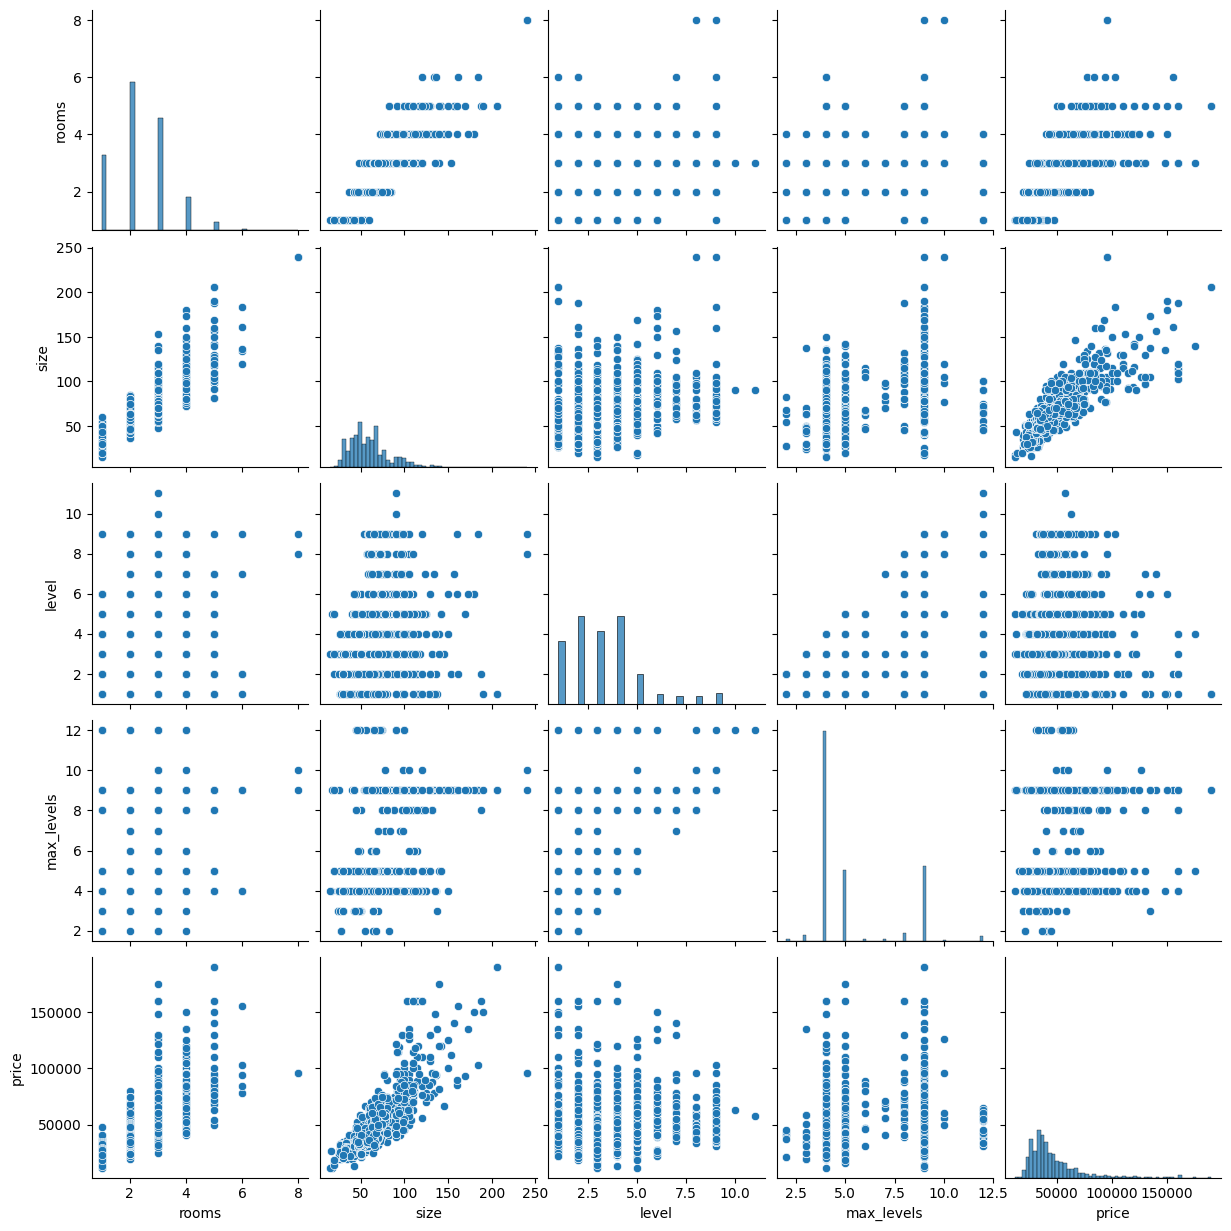

In [6]:

sns.pairplot(housing[['rooms', 'size', 'level', 'max_levels', 'price']])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

x_train = np.asanyarray(train_set[['size', 'max_levels']])
y_train = np.asanyarray(train_set[['price']])

In [9]:
from sklearn.linear_model import LinearRegression

LR_model = LinearRegression()

In [10]:
LR_model.fit(x_train, y_train)

LinearRegression()

In [11]:
x_test = np.asanyarray(test_set[['size', 'max_levels']])
y_test = np.asanyarray(test_set[['price']])

In [12]:
y_predict = LR_model.predict(x_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print(f'MAE: {mean_absolute_error(y_test, y_predict)}')
print(f'MSE: {np.sqrt(mean_squared_error(y_test, y_predict))}')

MAE: 7745.538188314143
MSE: 12748.5008511089


In [14]:
housing['price'].describe()

,price
count,1616.000000
mean,45617.487624
std,22726.766565
min,12000.000000
25%,32450.000000
50%,39500.000000
75%,52500.000000
max,190000.000000


In [18]:
from sklearn.metrics import r2_score

print(f'Modelimiz {int(r2_score(y_test, y_predict) * 100)} % togri ishlamoqda')

Modelimiz 69 % togri ishlamoqda
